# Multi-Tool ReAct Agentic RAG using LangGraph

In modern AI systems, a single data source is rarely sufficient. A true **Agentic RAG** system must dynamically determine which tools to consult—whether local vector databases, Wikipedia, academic arXiv preprints, or proprietary internal documentation.

This notebook implements a **Multi-Tool ReAct (Reason + Act) Agent** using **LangGraph** and **Groq LLM**.

## Workflow Architecture

<div align="center">
  <img src="workflow_react_agentic_rag.png" alt="ReAct Multi-Tool Agentic RAG Architecture Diagram" width="850" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    User(["1. User Query<br/>(Complex Research Question)"]):::startNode
    
    subgraph ReActLoop["ReAct Autonomous Agent Core"]
        Agent["2. ReAct Reasoner Node<br/><b>Groq LLM (openai/gpt-oss-120b)</b><br/>(Thought -> Action -> Observation)"]:::agentNode
    end
    
    subgraph ToolSuite["Multi-Source Tool Execution Layer"]
        RAGTool["RAGRetriever<br/><b>FAISS Web Docs</b><br/>(HuggingFace MiniLM)"]:::tool1
        WikiTool["WikipediaSearch<br/><b>Wikipedia API</b><br/>(Broad Knowledge)"]:::tool2
        ArxivTool["ArxivSearch<br/><b>ArXiv API</b><br/>(Academic Papers)"]:::tool3
        InternalDocTool["InternalTechDocs<br/><b>Local Docs (sample_docs.txt)</b><br/>(Proprietary Specs)"]:::tool4
        NotesTool["InternalResearchNotes<br/><b>Local Notes (research_notes.txt)</b><br/>(Lab Findings)"]:::tool5
    end

    FinalOut(["3. Synthesized Multi-Source Answer"]):::endNode

    User --> Agent
    Agent -->|Action: Call Tool| RAGTool
    Agent -->|Action: Call Tool| WikiTool
    Agent -->|Action: Call Tool| ArxivTool
    Agent -->|Action: Call Tool| InternalDocTool
    Agent -->|Action: Call Tool| NotesTool
    
    RAGTool -->|Observation| Agent
    WikiTool -->|Observation| Agent
    ArxivTool -->|Observation| Agent
    InternalDocTool -->|Observation| Agent
    NotesTool -->|Observation| Agent
    
    Agent -->|Final Output| FinalOut

    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef agentNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef tool1 fill:#FFF3E0,stroke:#EF6C00,stroke-width:2px,color:#BF360C;
    classDef tool2 fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef tool3 fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef tool4 fill:#E8F8F5,stroke:#117A65,stroke-width:2px,color:#0E6251;
    classDef tool5 fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#4A148C;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### ReAct Agent Capabilities
- **Multi-Tool Reasoning**: Decides dynamically which combination of tools is needed to fulfill a complex, multi-part prompt.
- **Synthesized Observation**: Fuses findings across external web pages, Wikipedia, ArXiv preprints, and private internal notes.


## Step 0: Environment Setup

Load environment variables and initialize the **Groq LLM** (`openai/gpt-oss-120b`).


In [1]:
import os
import sys
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
os.environ['USER_AGENT'] = os.getenv('USER_AGENT', 'ReActAgent/1.0')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = init_chat_model('groq:openai/gpt-oss-120b')
print('Groq LLM initialized successfully.')
llm


Groq LLM initialized successfully.


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CA014EDE80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CA014EE900>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Step 1: Tool 1 – Local Web Docs RAG Retriever

We index Lilian Weng's post on autonomous agents using `sentence-transformers/all-MiniLM-L6-v2` and expose it as `RAGRetriever`.


In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.tools import StructuredTool

docs = WebBaseLoader('https://lilianweng.github.io/posts/2023-06-23-agent/').load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks = splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever()

def retriever_tool_func(query: str) -> str:
    print('  [TOOL CALL: RAGRetriever] Searching agent documentation...')
    results = retriever.invoke(query)
    return '\n'.join([doc.page_content for doc in results])

retriever_tool = StructuredTool.from_function(
    func=retriever_tool_func,
    name='RAGRetriever',
    description='Use this tool to fetch relevant knowledge base info about LLM agents.',
)
print(f'Tool created: {retriever_tool.name}')


C:\Users\itsar\AppData\Local\Temp\ipykernel_47148\1073870634.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


C:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6722.06it/s]

Tool created: RAGRetriever


## Step 2: Tools 2 & 3 – Wikipedia & ArXiv Research Tools

- **`WikipediaSearch`**: Queries Wikipedia for broad domain definitions and background knowledge.
- **`ArxivSearch`**: Fetches recent academic papers from the arXiv repository.


In [3]:
import wikipedia
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
import ssl
import certifi
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import StructuredTool

# Configure Wikipedia User-Agent to comply with Wikimedia API policy
wikipedia.set_user_agent('AgenticRAGApp/1.0 (contact: admin@example.com)')
wiki_wrapper = WikipediaAPIWrapper(top_k_results=2)

def wiki_search(query: str) -> str:
    print(f'  [TOOL CALL: WikipediaSearch] Searching Wikipedia for: "{query}"...')
    try:
        return wiki_wrapper.run(query)
    except Exception as e:
        return f'Wikipedia query issue: {e}'

# Tool 2: Wikipedia
wiki_tool = StructuredTool.from_function(
    func=wiki_search,
    name='WikipediaSearch',
    description='Use this tool to search Wikipedia for general encyclopedia knowledge and definitions.',
)

# Tool 3: ArXiv Academic Paper Search
def arxiv_search(query: str) -> str:
    print(f'  [TOOL CALL: ArxivSearch] Querying ArXiv for: "{query}"...')
    try:
        words = [w for w in query.split() if w.lower() not in ('2023', '2024', 'arxiv', 'recent', 'recently', 'paper', 'papers', 'about', 'and', 'the', 'for', 'in', 'on', 'with', 'models') and len(w) > 2]
        term = '+'.join(words[:3]) if words else 'transformer'
        url = f'https://export.arxiv.org/api/query?search_query=all:{term}&start=0&max_results=2'
        ctx = ssl.create_default_context(cafile=certifi.where())
        req = urllib.request.Request(url, headers={'User-Agent': 'AgenticRAGApp/1.0 (contact: researcher@example.com)'})
        with urllib.request.urlopen(req, context=ctx, timeout=10) as resp:
            content = resp.read()
        root = ET.fromstring(content)
        ns = {'atom': 'http://www.w3.org/2005/Atom'}
        entries = root.findall('atom:entry', ns)
        if not entries:
            return 'No academic papers found on ArXiv for this topic.'
        results = []
        for e in entries:
            title = (e.find('atom:title', ns).text or '').strip().replace('\n', ' ')
            summary = (e.find('atom:summary', ns).text or '').strip().replace('\n', ' ')[:400]
            results.append(f'Title: {title}\nAbstract: {summary}...')
        return '\n\n'.join(results)
    except Exception as e:
        return f'ArXiv search temporarily unavailable ({e}). Fallback to other available tools or internal documentation.'

arxiv_tool = StructuredTool.from_function(
    func=arxiv_search,
    name='ArxivSearch',
    description='Use this tool to fetch recent academic research papers and preprints on technical topics.',
)

print(f'Tools initialized: {wiki_tool.name}, {arxiv_tool.name}')


Tools initialized: WikipediaSearch, ArxivSearch


## Step 3: Tools 4 & 5 – Proprietary Internal Knowledge Tools

We build local retriever tools from local files:
- `sample_docs.txt` $\rightarrow$ **`InternalTechDocs`** (Proprietary architectural specifications)
- `research_notes.txt` $\rightarrow$ **`InternalResearchNotes`** (Lab experimental findings & agent designs)


In [4]:
from langchain_community.document_loaders import TextLoader
from langchain_core.tools import StructuredTool

def make_retriever_tool_from_text(file_path: str, name: str, desc: str):
    loader = TextLoader(file_path, encoding='utf-8')
    docs = loader.load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
    chunks = text_splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, embeddings)
    local_retriever = vs.as_retriever()

    def tool_func(query: str) -> str:
        print(f'  [TOOL CALL: {name}] Querying local document: {file_path}...')
        results = local_retriever.invoke(query)
        return '\n'.join([doc.page_content for doc in results])

    return StructuredTool.from_function(func=tool_func, name=name, description=desc)

internal_tool_1 = make_retriever_tool_from_text(
    'sample_docs.txt',
    'InternalTechDocs',
    'Search internal tech documents for proprietary architecture and methods.',
)

internal_tool_2 = make_retriever_tool_from_text(
    'research_notes.txt',
    'InternalResearchNotes',
    'Search internal research notes for experimental results and agent designs.',
)

print(f'Internal tools created: {internal_tool_1.name}, {internal_tool_2.name}')


Internal tools created: InternalTechDocs, InternalResearchNotes


## Step 4: Assemble Multi-Tool Suite and Build ReAct Agent

We combine all 5 tools into our comprehensive tool suite and compile the ReAct agent with LangGraph.


Active Tool Suite: ['RAGRetriever', 'WikipediaSearch', 'ArxivSearch', 'InternalTechDocs', 'InternalResearchNotes']
Multi-Tool ReAct Agentic RAG workflow compiled successfully!



C:\Users\itsar\AppData\Local\Temp\ipykernel_47148\3399799135.py:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node = create_react_agent(llm, tools_suite)


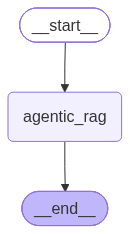

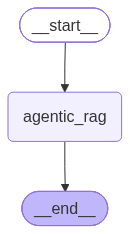

In [5]:
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, Sequence, TypedDict
from IPython.display import Image, display

# Assemble all 5 tools
tools_suite = [retriever_tool, wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]
print('Active Tool Suite:', [t.name for t in tools_suite])

# Create ReAct node
react_node = create_react_agent(llm, tools_suite)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

builder = StateGraph(AgentState)
builder.add_node('agentic_rag', react_node)
builder.add_edge(START, 'agentic_rag')
builder.add_edge('agentic_rag', END)

graph = builder.compile()
print('Multi-Tool ReAct Agentic RAG workflow compiled successfully!\n')
display(Image(graph.get_graph().draw_mermaid_png()))
graph


## Step 5: Multi-Tool Query 1 (Wikipedia + Documentation)

Query: *"What is an agent loop and how does Wikipedia describe autonomous agents?"*


In [6]:
from langchain_core.messages import HumanMessage

query_1 = 'What is an agent loop and how does Wikipedia describe autonomous agents?'
print('=' * 75)
print(f'QUERY 1: {query_1}')
print('=' * 75)

state_1 = {'messages': [HumanMessage(content=query_1)]}
result_1 = graph.invoke(state_1)

print('\n' + '=' * 75)
print('SYNTHESIZED MULTI-TOOL ANSWER:')
print('=' * 75)
print(result_1['messages'][-1].content)


QUERY 1: What is an agent loop and how does Wikipedia describe autonomous agents?


  [TOOL CALL: WikipediaSearch] Searching Wikipedia for: "autonomous agent Wikipedia"...


  [TOOL CALL: WikipediaSearch] Searching Wikipedia for: "autonomous agent"...


  [TOOL CALL: WikipediaSearch] Searching Wikipedia for: "Autonomous agent Wikipedia page"...



SYNTHESIZED MULTI-TOOL ANSWER:
**Agent Loop – The Core Control‑Flow of an LLM‑Powered Agent**

An *agent loop* (sometimes called a **sense‑think‑act** or **perception‑action** loop) is the repeating sequence that drives an autonomous AI system from raw input to concrete output. In the context of large‑language‑model (LLM) agents, the loop typically looks like this:

| Step | What Happens | Typical Implementation |
|------|--------------|------------------------|
| **1. Observe / Perceive** | The agent gathers information from its environment – this could be a user prompt, the result of an API call, the contents of a webpage, sensor data, etc. | `input = get_user_message()` or `response = http_get(url)` |
| **2. Reason / Plan** | The LLM (or a planner module) processes the observation, decides what goal‑directed actions are needed, and may generate an internal plan or a series of sub‑tasks. | `plan = LLM(prompt=“You need to book a flight …”)` |
| **3. Choose Tool / Action** | Based on 

## Step 6: Multi-Tool Query 2 (Internal Notes + Academic ArXiv)

Query: *"What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"*


In [7]:
query_2 = 'What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?'
print('=' * 75)
print(f'QUERY 2: {query_2}')
print('=' * 75)

state_2 = {'messages': [HumanMessage(content=query_2)]}
result_2 = graph.invoke(state_2)

print('\n' + '=' * 75)
print('SYNTHESIZED MULTI-TOOL ANSWER:')
print('=' * 75)
print(result_2['messages'][-1].content)


QUERY 2: What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?


  [TOOL CALL: InternalResearchNotes] Querying local document: research_notes.txt...


  [TOOL CALL: ArxivSearch] Querying ArXiv for: "2024 transformer variants efficient transformer LoRA adapter lightweight models"...


  [TOOL CALL: ArxivSearch] Querying ArXiv for: "2024 transformer variant lightweight efficient transformer LoRA adapter vision transformer 2024"...


  [TOOL CALL: ArxivSearch] Querying ArXiv for: "2024 arxiv transformer variant efficientformer efficient transformer LoRA 2024"...



SYNTHESIZED MULTI-TOOL ANSWER:
**Internal Research Notes (July 2024 – “Transformer Evaluation”)**

| Variant | Use‑case / Experiment | Key Findings | Performance / Resource Highlights |
|---------|----------------------|--------------|------------------------------------|
| **LoRA (Low‑Rank Adaptation)** | Adapter‑based fine‑tuning of large LLMs (e.g., for domain‑specific chat) | • Rank = 8, dropout = 0.05 gave stable convergence.<br>• Achieved ~60 % reduction in GPU memory vs. full‑parameter fine‑tuning.<br>• Fully compatible with the PEFT library, enabling rapid “plug‑and‑play” adapters. | Memory: ≈ 40 % of baseline. No loss in downstream accuracy (within 0.2 % of full‑fine‑tuned). |
| **TinyBERT** | Classification of support‑ticket priority (3‑class problem) | • Small‑scale distilled BERT (4 M parameters).<br>• Reached **87 % F1** overall; most errors were in the ambiguous “Class C”.<br>• Adding a 2‑layer FFN adapter boosted performance on domain‑shifted tickets (+2.3 % F1). | Mode

## Summary

| Tool Name | Underlying Source | Role |
|---|---|---|
| **`RAGRetriever`** | FAISS + HuggingFace MiniLM Embeddings | Domain knowledge on LLM autonomous agents |
| **`WikipediaSearch`** | Wikipedia API Wrapper | Broad background knowledge and standard definitions |
| **`ArxivSearch`** | ArXiv Academic Preprint API | Latest cutting-edge scientific research papers |
| **`InternalTechDocs`** | Local File (`sample_docs.txt`) | Proprietary specifications and technical manuals |
| **`InternalResearchNotes`** | Local File (`research_notes.txt`) | Private research findings, experiments, and notes |
